# 01 — Data Exploration

**Master's Thesis — Heterogeneous Effects of AI Tool Adoption on Developer Job Satisfaction**

This notebook is a first pass at understanding the 2025 Stack Overflow Developer Survey. The goal here is *not* to clean or model anything yet — just to see what we have: how many rows and columns, what the key variables look like, and where the missingness is.

We focus early attention on the variables that matter for the thesis:
- **Treatment:** AI tool adoption (`AISelect`)
- **Outcome:** Job satisfaction (`JobSat`)
- **Key moderators:** experience (`WorkExp`, `YearsCode`), organization size (`OrgSize`), role (`DevType`)
- **Covariates:** age, education, country, industry, remote work, compensation

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

## Load the data

The raw survey lives in `data/raw/`. We load both the responses and the schema (the schema maps each column name to the full question text, which is very handy for a survey this wide).

In [2]:
RAW = "../data/raw/"

df = pd.read_csv(RAW + "survey_results_public.csv", low_memory=False)
schema = pd.read_csv(RAW + "survey_results_schema.csv", encoding="utf-8-sig")

print(f"Responses: {df.shape[0]:,} rows  ×  {df.shape[1]} columns")
print(f"Schema:    {schema.shape[0]} question entries")

Responses: 49,191 rows  ×  172 columns
Schema:    139 question entries


### A small helper: look up what a column means

With ~170 columns, it's easy to lose track of what each one is. This helper prints the full question text for any column.

In [3]:
def question(colname):
    """Return the full question text for a given column name."""
    match = schema.loc[schema["qname"] == colname, "question"]
    if len(match):
        return match.iloc[0]
    return "(not found in schema)"

# Example
for col in ["AISelect", "JobSat", "WorkExp", "OrgSize", "DevType"]:
    print(f"{col:12s} → {question(col)}")

AISelect     → Do you currently use AI tools in your development process?
JobSat       → How satisfied are you in your current professional developer role?
WorkExp      → How many years of professional work experience do you have? Please round to the nearest whole number, excluding any decimal points.  If your answer is '0', please leave blank.
OrgSize      → Approximately how many people are employed by your employer?  This should only include your primary company, and if there was more than one employer please consider the one you spent most of your time working for in the past year.
DevType      → Which of the following describes your current job or the job you had for the most time in the past year?


## First look at the data

In [4]:
df.head()

,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,AILearnHow,YearsCode,DevType,OrgSize,ICorPM,RemoteWork,PurchaseInfluence,TechEndorseIntro,TechEndorse_1,TechEndorse_2,TechEndorse_3,TechEndorse_4,TechEndorse_5,TechEndorse_6,TechEndorse_7,TechEndorse_8,TechEndorse_9,TechEndorse_13,TechEndorse_13_TEXT,TechOppose_1,TechOppose_2,TechOppose_3,TechOppose_5,TechOppose_7,TechOppose_9,TechOppose_11,TechOppose_13,TechOppose_16,TechOppose_15,TechOppose_15_TEXT,Industry,JobSatPoints_1,JobSatPoints_2,JobSatPoints_3,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,JobSatPoints_13,JobSatPoints_14,JobSatPoints_15,JobSatPoints_16,JobSatPoints_15_TEXT,AIThreat,NewRole,ToolCountWork,ToolCountPersonal,Country,Currency,CompTotal,LanguageChoice,LanguageHaveWorkedWith,LanguageWantToWorkWith,LanguageAdmired,LanguagesHaveEntry,LanguagesWantEntry,DatabaseChoice,DatabaseHaveWorkedWith,DatabaseWantToWorkWith,DatabaseAdmired,DatabaseHaveEntry,DatabaseWantEntry,PlatformChoice,PlatformHaveWorkedWith,PlatformWantToWorkWith,PlatformAdmired,PlatformHaveEntry,PlatformWantEntry,WebframeChoice,WebframeHaveWorkedWith,WebframeWantToWorkWith,WebframeAdmired,WebframeHaveEntry,WebframeWantEntry,DevEnvsChoice,DevEnvsHaveWorkedWith,DevEnvsWantToWorkWith,DevEnvsAdmired,DevEnvHaveEntry,DevEnvWantEntry,SOTagsHaveWorkedWith,SOTagsWantToWorkWith,SOTagsAdmired,SOTagsHaveEntry,SOTagsWant Entry,OpSysPersonal use,OpSysProfessional use,OfficeStackAsyncHaveWorkedWith,OfficeStackAsyncWantToWorkWith,OfficeStackAsyncAdmired,OfficeStackHaveEntry,OfficeStackWantEntry,CommPlatformHaveWorkedWith,CommPlatformWantToWorkWith,CommPlatformAdmired,CommPlatformHaveEntr,CommPlatformWantEntr,AIModelsChoice,AIModelsHaveWorkedWith,AIModelsWantToWorkWith,AIModelsAdmired,AIModelsHaveEntry,AIModelsWantEntry,SOAccount,SOVisitFreq,SODuration,SOPartFreq,SO_Dev_Content,SO_Actions_1,SO_Actions_16,SO_Actions_3,SO_Actions_4,SO_Actions_5,SO_Actions_6,SO_Actions_9,SO_Actions_7,SO_Actions_10,SO_Actions_15,SO_Actions_15_TEXT,SOComm,SOFriction,AISelect,AISent,AIAcc,AIComplex,AIToolCurrently partially AI,AIToolDon't plan to use AI for this task,AIToolPlan to partially use AI,AIToolPlan to mostly use AI,AIToolCurrently mostly AI,AIFrustration,AIExplain,AIAgents,AIAgentChange,AIAgent_Uses,AgentUsesGeneral,AIAgentImpactSomewhat agree,AIAgentImpactNeutral,AIAgentImpactSomewhat disagree,AIAgentImpactStrongly agree,AIAgentImpactStrongly disagree,AIAgentChallengesNeutral,AIAgentChallengesSomewhat disagree,AIAgentChallengesStrongly agree,AIAgentChallengesSomewhat agree,AIAgentChallengesStrongly disagree,AIAgentKnowledge,AIAgentKnowWrite,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps,14.0,"Developer, mobile",20 to 99 employees,People manager,Remote,"Yes, I influenced the purchase of a substantia...",Work,10.0,7.0,9.0,6.0,3.0,11.0,12.0,1.0,8.0,14.0,NaN,15.0,7.0,8.0,12.0,11.0,1.0,6.0,13.0,3.0,16.0,NaN,Fintech,3.0,1.0,4.0,9.0,5.0,10.0,12.0,11.0,2.0,6.0,7.0,13.0,14.0,15.0,8.0,NaN,I'm not sure,I have neither consider or transitioned into a...,7.0,3.0,Ukraine,EUR European Euro,52800.0,Yes,Bash/Shell (all shells);Dart;SQL,Dart,Dart,NaN,NaN,Yes,Cloud Firestore;PostgreSQL,NaN,NaN,NaN,NaN,Yes,Amazon Web Services (AWS);Cloudflare;Firebase;...,NaN,NaN,NaN,NaN,No,NaN,NaN,NaN,NaN,NaN,Yes,Android Studio;Notepad++;Visual Studio;Visual ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Windows;MacOS;Android,Windows;MacOS;Android;iOS;iPadOS,Confluence;GitHub;GitLab;Jira;Markdo

In [5]:
df.info(verbose=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49191 entries, 0 to 49190
Columns: 172 entries, ResponseId to JobSat
dtypes: float64(52), int64(1), object(119)
memory usage: 64.6+ MB


## Missingness

Survey data is missing-heavy by design — most questions are optional, and the survey randomizes some blocks. Let's see how complete each column is, then zoom in on the variables we actually care about.

In [6]:
missing = (df.isna().mean() * 100).sort_values(ascending=False)
missing_df = missing.to_frame("pct_missing").round(1)
print("Most incomplete columns:")
missing_df.head(20)

Most incomplete columns:


,pct_missing
AIAgentObsWrite,99.5
SOTagsWant Entry,99.1
SOTagsHaveEntry,99.1
AIModelsWantEntry,99.0
AIAgentOrchWrite,99.0
JobSatPoints_15_TEXT,98.7
AIAgentKnowWrite,98.4
AIModelsHaveEntry,98.4
SO_Actions_15_TEXT,98.3
AIAgentExtWrite,98.3


In [7]:
print("Most complete columns:")
missing_df.tail(20)

Most complete columns:


,pct_missing
TechEndorse_5,26.9
TechEndorse_7,26.9
TechEndorse_8,26.9
TechEndorse_9,26.9
TechEndorse_6,26.9
TechEndorse_13,26.9
AIThreat,26.7
PurchaseInfluence,23.9
TechEndorseIntro,23.7
WorkExp,12.8


## The variables that matter for the thesis

Let's isolate the columns that map onto our research design and check their completeness specifically.

In [8]:
key_vars = {
    "Treatment":  ["AISelect", "AISent", "AIAcc", "AIComplex", "AIThreat", "AIAgents"],
    "Outcome":    ["JobSat"],
    "Moderators": ["WorkExp", "YearsCode", "OrgSize", "DevType"],
    "Covariates": ["Age", "EdLevel", "Country", "Industry", "RemoteWork",
                   "ICorPM", "CompTotal"],
}

rows = []
for group, cols in key_vars.items():
    for c in cols:
        if c in df.columns:
            rows.append({
                "group": group,
                "column": c,
                "pct_missing": round(df[c].isna().mean() * 100, 1),
                "n_unique": df[c].nunique(),
                "question": question(c)[:70],
            })

key_summary = pd.DataFrame(rows)
key_summary

,group,column,pct_missing,n_unique,question
0,Treatment,AISelect,31.5,5,Do you currently use AI tools in your developm...
1,Treatment,AISent,32.0,6,How favorable is your stance on using AI tools...
2,Treatment,AIAcc,32.3,5,How much do you trust the accuracy of the outp...
3,Treatment,AIComplex,32.3,6,How well do the AI tools you use in your devel...
4,Treatment,AIThreat,26.7,3,Do you believe AI is a threat to your current ...
5,Treatment,AIAgents,35.1,6,Are you using AI agents in your work (developm...
6,Outcome,JobSat,45.8,11,How satisfied are you in your current professi...
7,Moderators,WorkExp,12.8,72,How many years of professional work experience...
8,Moderators,YearsCode,12.5,78,"Including any education, how many years have y..."
9,Moderators,OrgSize,30.5,9,Approximately how many people are employed by ...


## The treatment variable: AI tool adoption

`AISelect` is the question we'll use to define adopters vs. non-adopters. Let's see the actual response categories and their distribution.

In [9]:
print(question("AISelect"))
print()
df["AISelect"].value_counts(dropna=False)

Do you currently use AI tools in your development process?



AISelect
Yes, I use AI tools daily                      15883
NaN                                            15471
Yes, I use AI tools weekly                      5958
No, and I don't plan to                         5454
Yes, I use AI tools monthly or infrequently     4628
No, but I plan to soon                          1797
Name: count, dtype: int64

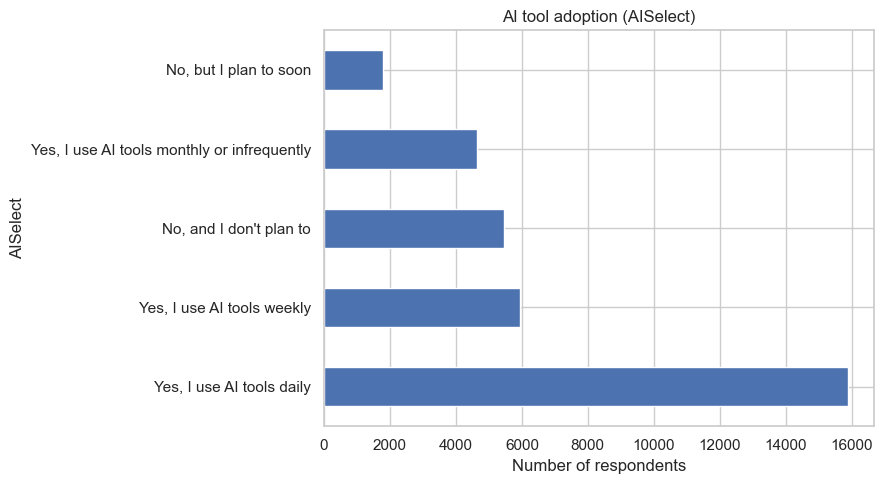

In [10]:
ax = df["AISelect"].value_counts().plot(kind="barh")
ax.set_title("AI tool adoption (AISelect)")
ax.set_xlabel("Number of respondents")
plt.tight_layout()
plt.show()

## The outcome: job satisfaction

`JobSat` is our primary outcome. Let's check whether it's numeric or categorical and see its distribution.

In [11]:
print(question("JobSat"))
print()
print(df["JobSat"].describe())
print()
df["JobSat"].value_counts(dropna=False).sort_index()

How satisfied are you in your current professional developer role?

count    26670.000000
mean         7.201950
std          1.997245
min          0.000000
25%          6.000000
50%          8.000000
75%          8.000000
max         10.000000
Name: JobSat, dtype: float64



JobSat
0.0       242
1.0       165
2.0       439
3.0       811
4.0       803
5.0      1896
6.0      3230
7.0      5590
8.0      6972
9.0      3598
10.0     2924
NaN     22521
Name: count, dtype: int64

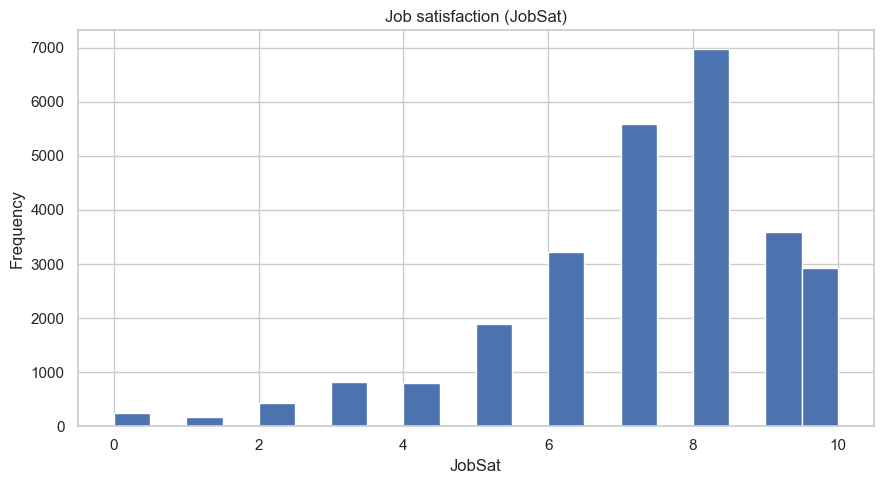

In [12]:
if pd.api.types.is_numeric_dtype(df["JobSat"]):
    ax = df["JobSat"].plot(kind="hist", bins=20)
    ax.set_title("Job satisfaction (JobSat)")
    ax.set_xlabel("JobSat")
    plt.tight_layout()
    plt.show()
else:
    print("JobSat is not numeric — inspect the categories above.")

## Key moderators

These are the variables the causal forest will explore for treatment-effect heterogeneity. The experience variables are central to hypotheses H1a/H1b.

In [13]:
print("WorkExp —", question("WorkExp"))
print()
print(df["WorkExp"].describe())
print()
print("=" * 60)
print()
print("YearsCode —", question("YearsCode"))
print()
print(df["YearsCode"].describe())
print()
# The two experience measures are related but distinct:
# WorkExp = professional work experience; YearsCode = total coding experience (incl. education)
valid = df[["WorkExp", "YearsCode"]].dropna()
corr = valid.corr().iloc[0, 1]
print(f"Correlation between WorkExp and YearsCode: {corr:.3f}  (n={len(valid):,})")
print()
# H1a/H1b experience cutoffs: junior = 0–5 years, senior = 10+ years (WorkExp)
for label, lo, hi in [("Junior (0–5 yrs)", 0, 5), ("Mid (6–9 yrs)", 6, 9), ("Senior (10+ yrs)", 10, 200)]:
    n = df["WorkExp"].between(lo, hi).sum()
    print(f"  {label:22s}: {n:,} respondents")

WorkExp — How many years of professional work experience do you have? Please round to the nearest whole number, excluding any decimal points.  If your answer is '0', please leave blank.

count    42893.000000
mean        13.367403
std         10.800117
min          1.000000
25%          5.000000
50%         10.000000
75%         20.000000
max        100.000000
Name: WorkExp, dtype: float64


YearsCode — Including any education, how many years have you been coding in total?  Please round to the nearest whole number, excluding any decimal points.

count    43042.000000
mean        16.570861
std         11.787610
min          1.000000
25%          8.000000
50%         14.000000
75%         24.000000
max        100.000000
Name: YearsCode, dtype: float64

Correlation between WorkExp and YearsCode: 0.837  (n=39,869)

  Junior (0–5 yrs)      : 12,203 respondents
  Mid (6–9 yrs)         : 6,769 respondents
  Senior (10+ yrs)      : 23,921 respondents


In [14]:
for col in ["OrgSize", "DevType"]:
    print(f"\n{'='*60}\n{col} — {question(col)}\n{'='*60}")
    print(df[col].value_counts(dropna=False).head(15))


OrgSize — Approximately how many people are employed by your employer?  This should only include your primary company, and if there was more than one employer please consider the one you spent most of your time working for in the past year.
OrgSize
NaN                                                   15013
20 to 99 employees                                     6688
100 to 499 employees                                   6109
Less than 20 employees                                 5600
10,000 or more employees                               4965
1,000 to 4,999 employees                               4156
500 to 999 employees                                   2361
Just me - I am a freelancer, sole proprietor, etc.     1763
5,000 to 9,999 employees                               1604
I don’t know                                            932
Name: count, dtype: int64

DevType — Which of the following describes your current job or the job you had for the most time in the past year?
DevType


## A first (purely descriptive) cut

A quick, **non-causal** look at the raw relationship between AI adoption and job satisfaction. This is exactly the kind of naive comparison the thesis will later improve on with causal methods — but it's a useful sanity check that the variables behave sensibly.

⚠️ This tells us nothing about causation yet — adopters and non-adopters differ in many ways.

In [15]:
if pd.api.types.is_numeric_dtype(df["JobSat"]):
    cut = (df.dropna(subset=["AISelect", "JobSat"])
             .groupby("AISelect")["JobSat"]
             .agg(["mean", "median", "count"])
             .sort_values("mean", ascending=False))
    print(cut.round(2))

                                             mean  median  count
AISelect                                                        
Yes, I use AI tools daily                    7.29     8.0  12599
Yes, I use AI tools weekly                   7.14     7.0   4353
No, and I don't plan to                      7.14     8.0   3643
No, but I plan to soon                       7.11     8.0   1135
Yes, I use AI tools monthly or infrequently  7.11     7.0   3188


## Analysis sample size

How many usable observations do we actually have once we apply the treatment definition from the proposal (daily/weekly users vs. no use and no plan to use) and require non-missing `JobSat`?

In [16]:
adopters    = df["AISelect"].isin(["Yes, I use AI tools daily", "Yes, I use AI tools weekly"])
non_adopters = df["AISelect"] == "No, and I don't plan to"
excluded    = df["AISelect"].isin(["Yes, I use AI tools monthly or infrequently", "No, but I plan to soon"])

df["treat_binary"] = np.where(adopters, 1, np.where(non_adopters, 0, np.nan))

print("Treatment assignment from full sample:")
print(f"  Adopters (daily + weekly) : {adopters.sum():,}")
print(f"  Non-adopters (no + no plan): {non_adopters.sum():,}")
print(f"  Excluded (monthly / plan to): {excluded.sum():,}")
print(f"  Missing AISelect           : {df['AISelect'].isna().sum():,}")
print()

# Minimum required: treatment + outcome
core = df.dropna(subset=["treat_binary", "JobSat"])
print(f"Complete on treatment + JobSat: {len(core):,} rows")
print(f"  Adopters:     {(core['treat_binary']==1).sum():,}")
print(f"  Non-adopters: {(core['treat_binary']==0).sum():,}")
print()

# Add the key moderators and covariates
analysis_cols = ["treat_binary", "JobSat", "WorkExp", "YearsCode",
                 "OrgSize", "DevType", "Age", "EdLevel",
                 "Country", "Industry", "RemoteWork", "ICorPM"]
full_complete = df[analysis_cols].dropna()
print(f"Complete on all key variables: {len(full_complete):,} rows")
print()
print("Missingness (%) in the treatment+JobSat sample:")
print((core[analysis_cols].isna().mean() * 100).round(1).to_string())

Treatment assignment from full sample:
  Adopters (daily + weekly) : 21,841
  Non-adopters (no + no plan): 5,454
  Excluded (monthly / plan to): 6,425
  Missing AISelect           : 15,471

Complete on treatment + JobSat: 20,595 rows
  Adopters:     16,952
  Non-adopters: 3,643

Complete on all key variables: 17,031 rows

Missingness (%) in the treatment+JobSat sample:


treat_binary     0.0
JobSat           0.0
WorkExp          2.3
YearsCode        0.7
OrgSize         13.8
DevType          0.0
Age              0.0
EdLevel          0.1
Country          0.0
Industry         4.5
RemoteWork      14.3
ICorPM          15.4


## Notes & next steps

Things to carry into the cleaning notebook (`02-data-cleaning.ipynb`):

**Treatment construction**
- Use `AISelect ∈ {daily, weekly}` → adopter (1) vs. `AISelect = "No, and I don't plan to"` → non-adopter (0).
- The ~6,400 "monthly/infrequent" and "plan to soon" respondents are excluded from the main analysis. Consider using them as a robustness or placebo group in `03`.
- Note: `WorkExp` is floored at 1 — respondents with 0 years were instructed to leave the field blank, so true zero-experience developers are coded as missing. Keep this in mind for the junior (0–5 yr) group definition in H1a.

**Outcome**
- `JobSat` is numeric (0–10). Treat as continuous for DML. Confirm left-skew isn't so bad that a rank or ordinal transformation is needed.
- 45.8% of the full sample is missing on `JobSat` — the effective analysis sample will be considerably smaller than 49k. Run the sample size cell above and document the number in the thesis.

**Covariates**
- `CompTotal` has ~50% missingness — likely too incomplete to include directly. Either impute (risky for compensation) or drop and rely on the remaining covariates. Do not carry into the cleaning notebook without a plan.
- Technology-stack columns (`Language*`, `Database*`, `Webframe*`, etc.) have ~95% missingness — exclude from the covariate set.
- `Country` (28% missing) and `OrgSize` (30.5% missing) are important for H2 and for confounding adjustment. Decide whether to impute or accept the smaller complete-case sample.

**Moderators**
- Both `WorkExp` and `YearsCode` can be used. They are highly correlated; in the causal forest use `WorkExp` as the primary (closer to the JD-R mechanism) and `YearsCode` as a robustness check.
- `AIThreat` (3 categories, 26.7% missing) is worth including as both a potential moderator and a mechanism variable — it captures the psychological cost of skill depreciation theorized in Channel 2.

**Schema gap**
- The schema covers 139 of the 172 columns. The missing entries are mostly derived/open-text columns; the `question()` helper will return "(not found in schema)" for them, which is fine.

*Observations so far:*

> (write your own notes here as you run the cells)